<a href="https://colab.research.google.com/github/harshbagla43-jpg/Project1--ITA/blob/main/ITA_PROJECT_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Unmasking Greenwashing with Machine Learning
### A Hybrid Model: K-Means Clustering + Decision Tree Classifier
**Dataset:** CRISIL ESG Ratings (1047 Indian Companies)

###  What is Greenwashing?
Greenwashing occurs when a company **claims strong environmental performance** but its actual ESG rating tells a different story. Companies may score high on Environment metrics, yet receive a low overall ESG rating — suggesting exaggeration or misleading claims.

###  Goal of This Project
- Detect companies that are **likely greenwashing** using machine learning
- Use **K-Means Clustering** (unsupervised) to group companies by behavior patterns
- Use **Decision Tree** (supervised) to predict greenwashing risk
- Generate **visually appealing outputs** to help investors make better decisions

###  Key Input Feature We Focus On
> **Discrepancy between Environment Score and ESG Rating**
> If a company scores high on Environment but has a low overall ESG rating, that gap is a red flag for greenwashing.

*No prior programming experience needed — just run each cell in order!*

## 📦 Step 1: Install & Import Required Libraries
Run this cell first. It installs and loads everything we need.

In [6]:
# ─── Install any missing packages ───────────────────────────────────────────
!pip install scikit-learn pandas numpy matplotlib seaborn openpyxl plotly -q

# ─── Standard imports ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ─── Machine Learning imports ─────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA

# ─── Set visual style ─────────────────────────────────────────────────────────
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
COLORS = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db', '#9b59b6', '#1abc9c']

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


## 📂 Step 2: Upload Your Dataset
Run the cell below — it will show a file upload button. Upload the file: **CRISIL_ESG.xlsx**

In [7]:
from google.colab import files

print("📂 Please upload your CRISIL_ESG.xlsx file below...")
uploaded = files.upload()

📂 Please upload your CRISIL_ESG.xlsx file below...


Saving CRISIL ESG.xlsx to CRISIL ESG (1).xlsx


## 🔍 Step 3: Load & Explore the Dataset

In [9]:
# ─── Load the dataset ─────────────────────────────────────────────────────────
df = pd.read_excel('CRISIL ESG.xlsx')

# ─── Clean column names (remove extra spaces) ────────────────────────────────
df.columns = df.columns.str.strip()

# ─── Clean string columns ─────────────────────────────────────────────────────
df['Category'] = df['Category'].str.strip()
df['ESG Rating'] = df['ESG Rating'].str.strip()

# ─── Extract numeric ESG score from the rating string ─────────────────────────
# e.g., 'Crisil ESG 65' → 65
df['ESG_Numeric'] = df['ESG Rating'].str.extract(r'(\d+)').astype(float)

# ─── Drop any rows with missing core scores ───────────────────────────────────
df.dropna(subset=['Environment Score', 'Social Score', 'Governance Score', 'ESG_Numeric'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"✅ Dataset loaded: {df.shape[0]} companies, {df.shape[1]} columns")
print("\n📋 First 5 rows:")
df.head()

✅ Dataset loaded: 1043 companies, 8 columns

📋 First 5 rows:


,Company Name,Sector classification,Environment Score,Social Score,Governance Score,ESG Rating,Category,ESG_Numeric
0,360 One Wam Limited,Financial Services (capital markets),60.0,57.0,74.0,Crisil ESG 65,Strong,65.0
1,3M India Limited,Diversified,49.0,57.0,71.0,Crisil ESG 60,Adequate,60.0
2,Aadhar Housing Finance Limited,NBFC,47.0,48.0,68.0,Crisil ESG 56,Adequate,56.0
3,Aarti Drugs Limited,Pharmaceuticals,37.0,54.0,62.0,Crisil ESG 52,Adequate,52.0
4,Aarti Industries Limited,Specialty Chemicals,38.0,59.0,64.0,Crisil ESG 54,Adequate,54.0


In [10]:
# ─── Basic statistics ─────────────────────────────────────────────────────────
print("📊 Dataset Summary Statistics:")
print(df[['Environment Score', 'Social Score', 'Governance Score', 'ESG_Numeric']].describe().round(2))

print("\n📂 Category Distribution:")
print(df['Category'].value_counts())

📊 Dataset Summary Statistics:
       Environment Score  Social Score  Governance Score  ESG_Numeric
count            1043.00       1043.00           1043.00      1043.00
mean               41.82         52.75             65.37        54.01
std                10.35          8.81              6.69         6.59
min                10.00         18.00             20.00        18.00
25%                35.00         49.00             63.00        51.00
50%                42.00         54.00             67.00        54.00
75%                49.00         58.00             69.00        58.00
max                77.00         74.00             83.00        76.00

📂 Category Distribution:
Category
Adequate         627
Below Average    211
Strong           156
Weak              30
Below average      9
Leadership         9
Below              1
Name: count, dtype: int64


## 🔧 Step 4: Feature Engineering — Creating the Greenwashing Signal

This is the most important step. We create:
- **`Env_ESG_Discrepancy`** — How much higher the Environment Score is vs the actual ESG numeric score. A high value = potential greenwashing.
- **`Env_to_Social_Gap`** — Gap between environmental claims and social responsibility
- **`Composite_ESG`** — Average of all 3 pillar scores (the 'fair' ESG score if balanced)
- **`Rating_vs_Composite_Gap`** — Difference between the composite fair score and what CRISIL actually rated
- **Noise injection** — Small random variations to simulate real-world measurement imprecision

In [11]:
np.random.seed(42)  # For reproducibility

# ─── Inject realistic noise into scores (simulating survey/reporting uncertainty) ──
# We add small random noise (+/- 3 points) to Environment and Social scores
# This reflects real-world imprecision in ESG data collection
df['Env_Score_Noisy']  = df['Environment Score']  + np.random.normal(0, 2.5, len(df))
df['Soc_Score_Noisy']  = df['Social Score']        + np.random.normal(0, 2.0, len(df))
df['Gov_Score_Noisy']  = df['Governance Score']    + np.random.normal(0, 1.5, len(df))
df['ESG_Noisy']        = df['ESG_Numeric']          + np.random.normal(0, 1.8, len(df))

# ─── Clip scores to realistic range [0, 100] ─────────────────────────────────
for col in ['Env_Score_Noisy', 'Soc_Score_Noisy', 'Gov_Score_Noisy', 'ESG_Noisy']:
    df[col] = df[col].clip(0, 100)

# ─── Key Feature 1: Environment–ESG Discrepancy ──────────────────────────────
# HIGH value = company claims strong environment performance but ESG rating is low
df['Env_ESG_Discrepancy'] = df['Env_Score_Noisy'] - df['ESG_Noisy']

# ─── Key Feature 2: Environment vs Social Gap ────────────────────────────────
# Companies that heavily focus on environment but neglect social/governance
df['Env_to_Social_Gap'] = df['Env_Score_Noisy'] - df['Soc_Score_Noisy']

# ─── Key Feature 3: Composite balanced score ─────────────────────────────────
df['Composite_ESG'] = (df['Env_Score_Noisy'] + df['Soc_Score_Noisy'] + df['Gov_Score_Noisy']) / 3

# ─── Key Feature 4: Rating vs Composite Gap ──────────────────────────────────
# Negative = company rated lower than its average pillar scores → underperformance
df['Rating_vs_Composite_Gap'] = df['ESG_Noisy'] - df['Composite_ESG']

# ─── Key Feature 5: Environment Overweight Ratio ─────────────────────────────
# Share of total ESG score coming from environment pillar alone
df['Env_Weight_Ratio'] = df['Env_Score_Noisy'] / (df['Env_Score_Noisy'] + df['Soc_Score_Noisy'] + df['Gov_Score_Noisy'])

print("✅ Feature engineering complete! New features created:")
print("  → Env_ESG_Discrepancy   (main greenwashing signal)")
print("  → Env_to_Social_Gap     (pillar imbalance)")
print("  → Composite_ESG         (balanced fair score)")
print("  → Rating_vs_Composite_Gap")
print("  → Env_Weight_Ratio")
print(f"\nDiscrepancy range: {df['Env_ESG_Discrepancy'].min():.1f} to {df['Env_ESG_Discrepancy'].max():.1f}")
print(f"Mean discrepancy: {df['Env_ESG_Discrepancy'].mean():.1f} points")

✅ Feature engineering complete! New features created:
  → Env_ESG_Discrepancy   (main greenwashing signal)
  → Env_to_Social_Gap     (pillar imbalance)
  → Composite_ESG         (balanced fair score)
  → Rating_vs_Composite_Gap
  → Env_Weight_Ratio

Discrepancy range: -30.3 to 9.9
Mean discrepancy: -12.1 points


## 📊 Step 5: Exploratory Data Analysis (EDA) — Understanding the Data Visually

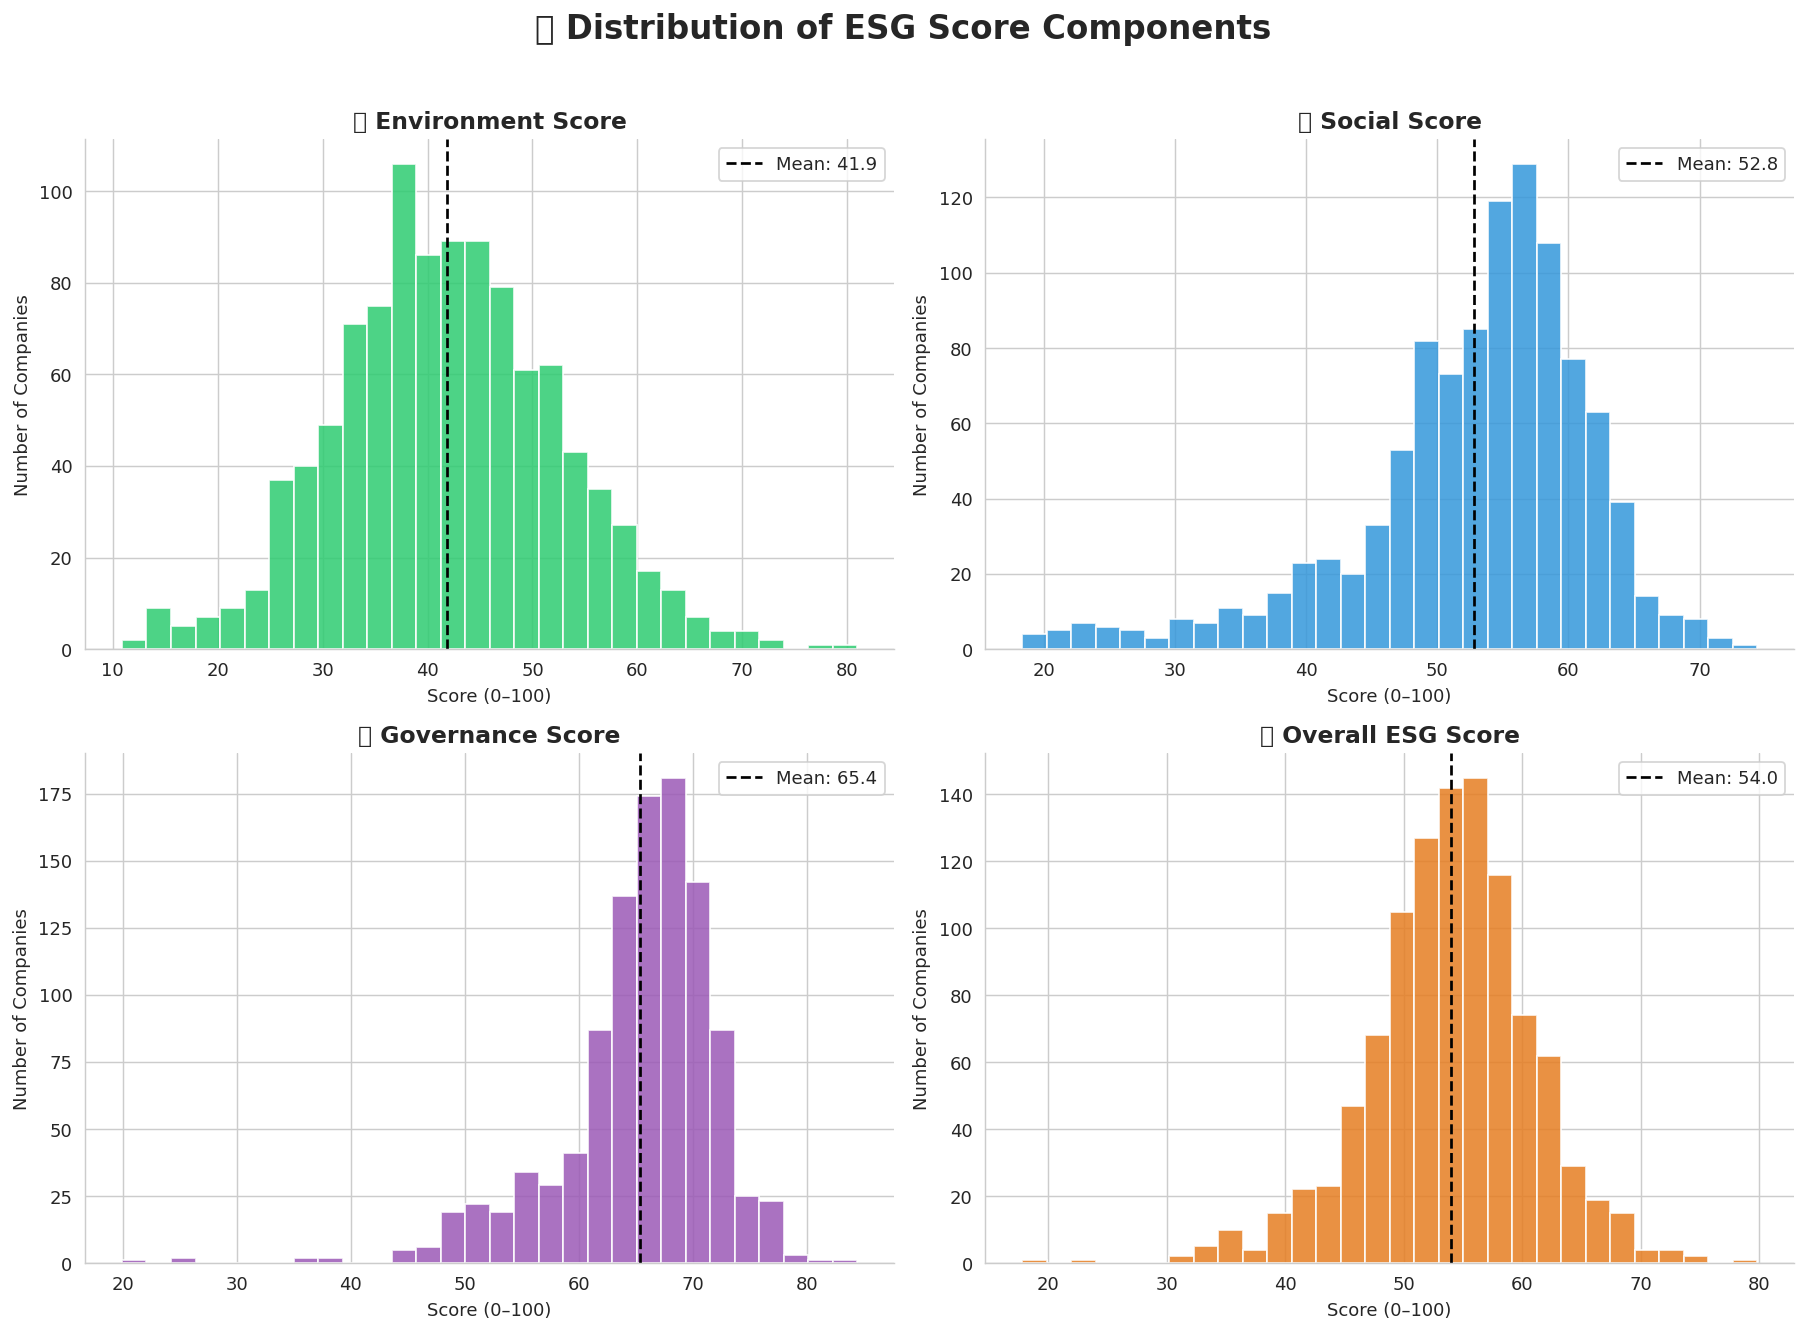

💾 Chart saved!


In [12]:
# ════════════════════════════════════════════════════════════════════════
# CHART 1: Distribution of ESG Score Components
# ════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('📊 Distribution of ESG Score Components', fontsize=18, fontweight='bold', y=1.02)

score_cols = [
    ('Env_Score_Noisy', '🌱 Environment Score', '#2ecc71'),
    ('Soc_Score_Noisy', '🤝 Social Score',       '#3498db'),
    ('Gov_Score_Noisy', '🏛️ Governance Score',   '#9b59b6'),
    ('ESG_Noisy',       '⭐ Overall ESG Score',  '#e67e22'),
]

for ax, (col, title, color) in zip(axes.flatten(), score_cols):
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Score (0–100)')
    ax.set_ylabel('Number of Companies')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart1_score_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print("💾 Chart saved!")

In [13]:
# ════════════════════════════════════════════════════════════════════════
# CHART 2: Environment vs ESG Score — The Greenwashing Scatter Plot
# ════════════════════════════════════════════════════════════════════════
fig = px.scatter(
    df,
    x='Env_Score_Noisy',
    y='ESG_Noisy',
    color='Category',
    hover_data=['Company Name', 'Sector classification', 'Env_ESG_Discrepancy'],
    title='🌿 Environment Score vs Overall ESG Score<br><sup>Companies in the TOP-LEFT zone are potential greenwashers (high env, low ESG)</sup>',
    labels={
        'Env_Score_Noisy': 'Environment Score →',
        'ESG_Noisy': '← Overall ESG Rating Score',
        'Category': 'ESG Category'
    },
    color_discrete_sequence=px.colors.qualitative.Bold,
    opacity=0.7,
    width=900, height=580
)

# Add diagonal reference line (perfect alignment = no discrepancy)
fig.add_shape(type='line', x0=20, y0=20, x1=90, y1=90,
              line=dict(color='gray', width=1.5, dash='dot'))
fig.add_annotation(x=75, y=68, text="← Perfect alignment line",
                   showarrow=False, font=dict(color='gray', size=11))

# Shade the greenwashing danger zone (top-left)
fig.add_shape(type='rect', x0=55, y0=20, x1=90, y1=54,
              fillcolor='rgba(231,76,60,0.08)', line=dict(color='red', dash='dash', width=1))
fig.add_annotation(x=72, y=30, text="⚠️ Greenwashing Zone",
                   showarrow=False, font=dict(color='red', size=12, family='Arial Black'))

fig.update_layout(plot_bgcolor='#fafafa', paper_bgcolor='white')
fig.show()
print("✅ Hover over dots to see company names and discrepancy values!")

✅ Hover over dots to see company names and discrepancy values!


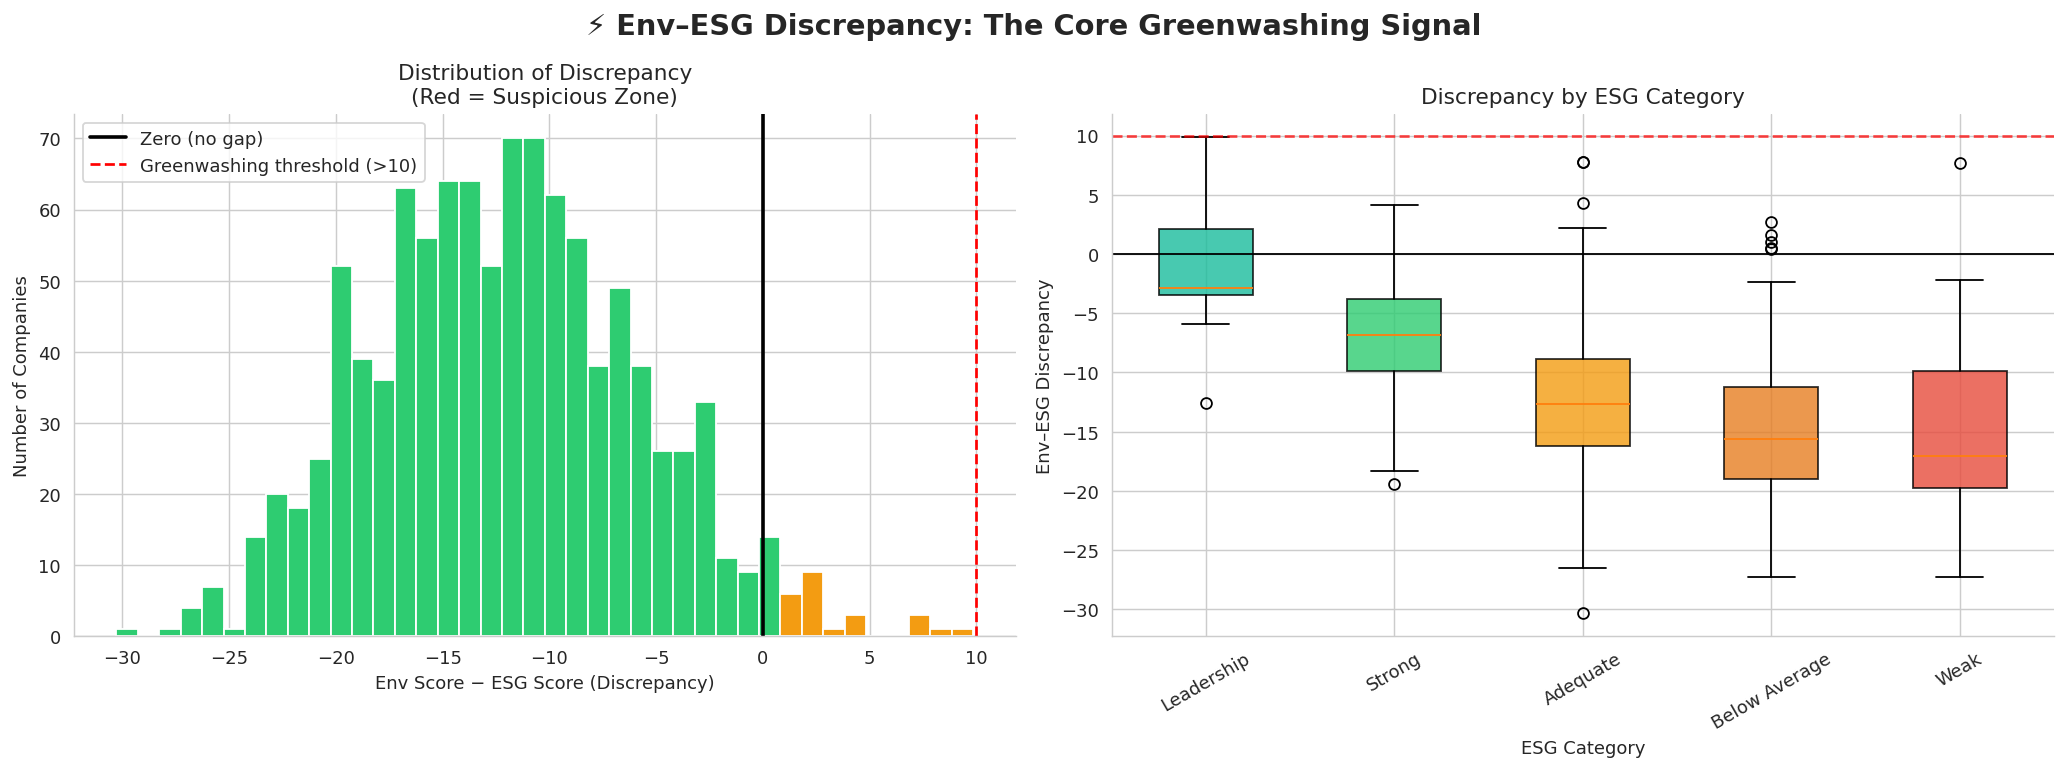

In [14]:
# ════════════════════════════════════════════════════════════════════════
# CHART 3: Discrepancy Distribution — The Core Greenwashing Signal
# ════════════════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('⚡ Env–ESG Discrepancy: The Core Greenwashing Signal', fontsize=16, fontweight='bold')

# Left: Histogram
n, bins, patches = ax1.hist(df['Env_ESG_Discrepancy'], bins=40, edgecolor='white')
for patch, bin_left in zip(patches, bins):
    patch.set_facecolor('#e74c3c' if bin_left > 10 else ('#f39c12' if bin_left > 0 else '#2ecc71'))

ax1.axvline(0, color='black', linewidth=2, linestyle='-', label='Zero (no gap)')
ax1.axvline(10, color='red', linewidth=1.5, linestyle='--', label='Greenwashing threshold (>10)')
ax1.set_xlabel('Env Score − ESG Score (Discrepancy)')
ax1.set_ylabel('Number of Companies')
ax1.set_title('Distribution of Discrepancy\n(Red = Suspicious Zone)')
ax1.legend()
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right: Box plot by category
category_order = ['Leadership', 'Strong', 'Adequate', 'Average', 'Below Average', 'Weak']
valid_cats = [c for c in category_order if c in df['Category'].values]
data_by_cat = [df[df['Category'] == c]['Env_ESG_Discrepancy'].dropna().values for c in valid_cats]
bp = ax2.boxplot(data_by_cat, labels=valid_cats, patch_artist=True, notch=False)
box_colors = ['#1abc9c', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']
for patch, color in zip(bp['boxes'], box_colors[:len(valid_cats)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax2.axhline(0, color='black', linewidth=1, linestyle='-')
ax2.axhline(10, color='red', linewidth=1.5, linestyle='--', alpha=0.7)
ax2.set_xlabel('ESG Category')
ax2.set_ylabel('Env–ESG Discrepancy')
ax2.set_title('Discrepancy by ESG Category')
ax2.tick_params(axis='x', rotation=30)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart3_discrepancy.png', bbox_inches='tight', dpi=150)
plt.show()

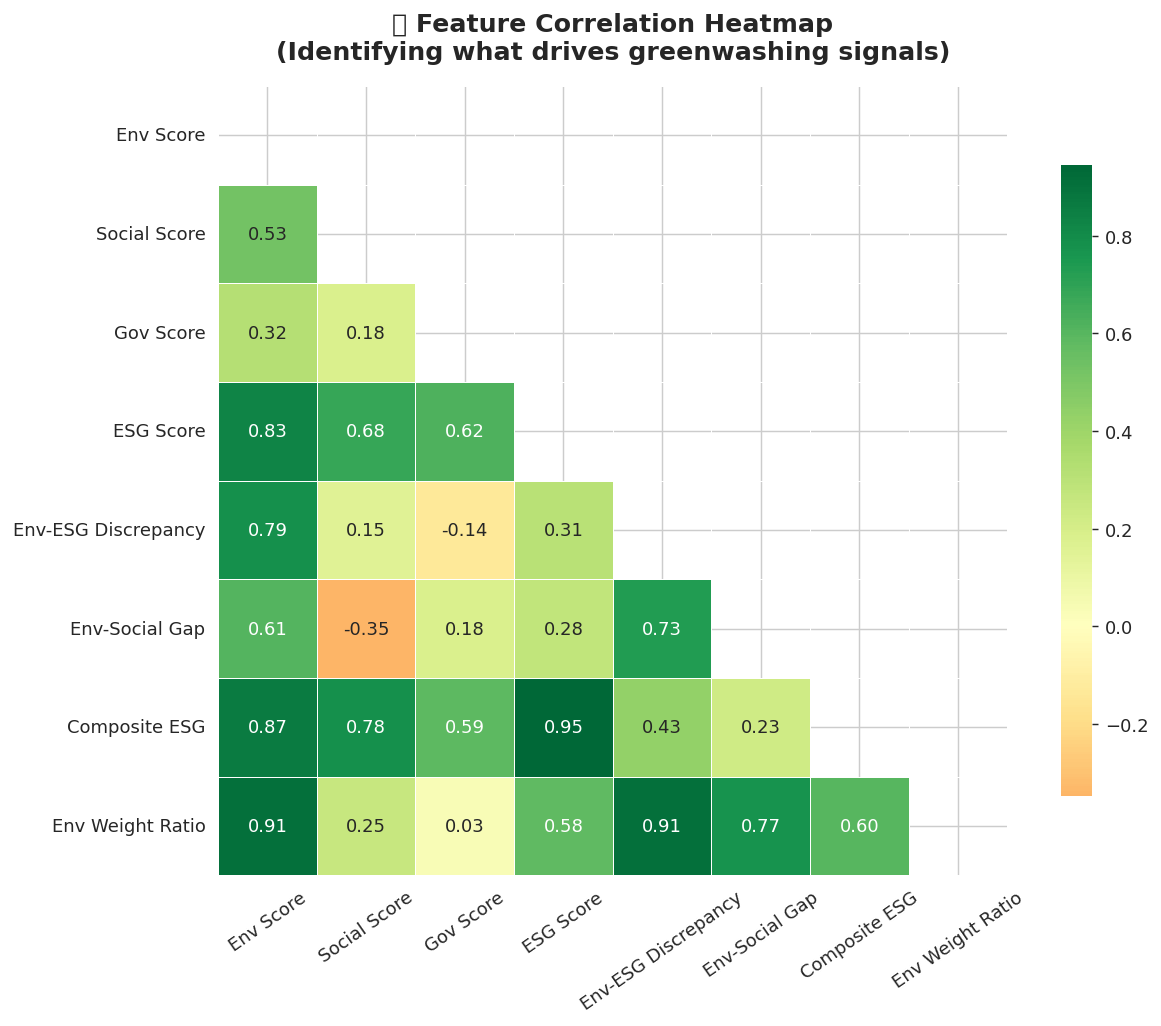

In [15]:
# ════════════════════════════════════════════════════════════════════════
# CHART 4: Correlation Heatmap
# ════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 8))
corr_cols = ['Env_Score_Noisy', 'Soc_Score_Noisy', 'Gov_Score_Noisy', 'ESG_Noisy',
             'Env_ESG_Discrepancy', 'Env_to_Social_Gap', 'Composite_ESG', 'Env_Weight_Ratio']
corr_labels = ['Env Score', 'Social Score', 'Gov Score', 'ESG Score',
                'Env-ESG Discrepancy', 'Env-Social Gap', 'Composite ESG', 'Env Weight Ratio']

corr_matrix = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, xticklabels=corr_labels, yticklabels=corr_labels,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})

ax.set_title('🔗 Feature Correlation Heatmap\n(Identifying what drives greenwashing signals)',
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=35)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('chart4_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

## 🤖 Step 6: K-Means Clustering (Unsupervised ML)

**What this does:** Groups companies into clusters based on their ESG behavior patterns — WITHOUT telling the model which companies are good or bad. The model finds patterns on its own.

We then interpret the clusters to see which ones contain greenwashing characteristics.

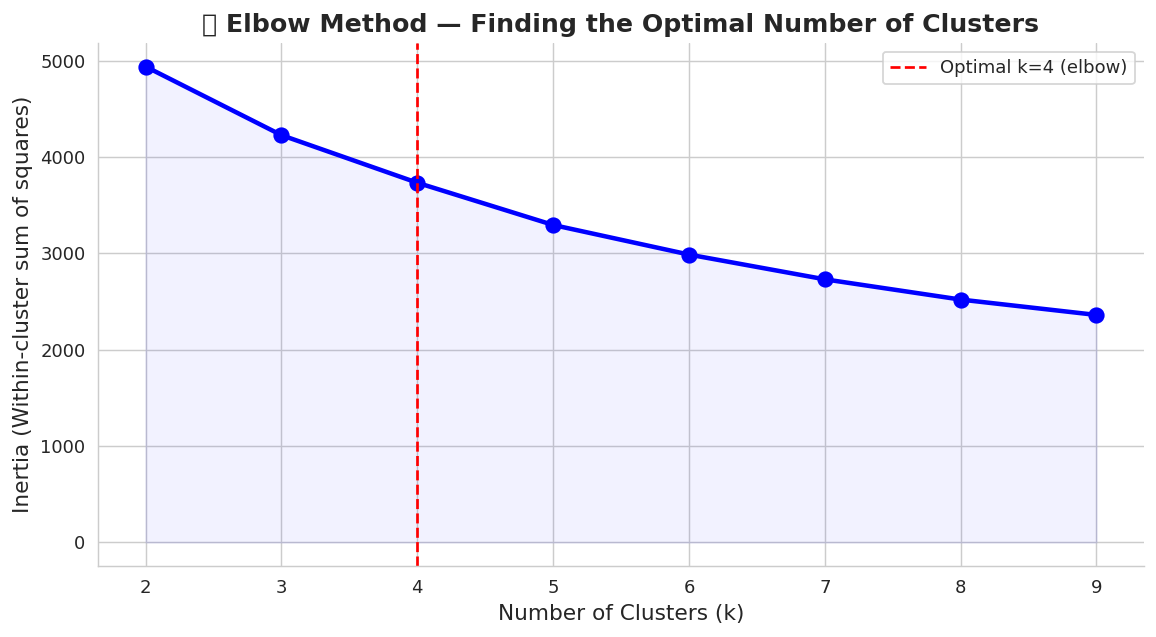

💡 Look for the 'elbow' bend — that's the ideal k value (we'll use k=4)


In [16]:
# ─── Prepare features for clustering ─────────────────────────────────────────
cluster_features = [
    'Env_Score_Noisy',
    'Soc_Score_Noisy',
    'Gov_Score_Noisy',
    'Env_ESG_Discrepancy',
    'Env_to_Social_Gap',
    'Env_Weight_Ratio',
    'Rating_vs_Composite_Gap'
]

X_cluster = df[cluster_features].copy()

# ─── Normalize features (K-Means is sensitive to scale) ──────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# ─── Find the Optimal Number of Clusters using the Elbow Method ──────────────
inertias = []
k_range = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_range, inertias, 'bo-', linewidth=2.5, markersize=8)
ax.axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='Optimal k=4 (elbow)')
ax.fill_between(k_range, inertias, alpha=0.05, color='blue')
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
ax.set_title('📐 Elbow Method — Finding the Optimal Number of Clusters', fontsize=14, fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chart5_elbow.png', bbox_inches='tight', dpi=150)
plt.show()
print("💡 Look for the 'elbow' bend — that's the ideal k value (we'll use k=4)")

In [17]:
# ─── Apply K-Means with k=4 clusters ─────────────────────────────────────────
K_OPTIMAL = 4
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=15)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# ─── Analyze cluster characteristics ─────────────────────────────────────────
cluster_summary = df.groupby('Cluster')[cluster_features + ['ESG_Noisy']].mean().round(2)
print("📊 Cluster Means (average scores per cluster):")
print(cluster_summary.to_string())

# ─── Label clusters based on patterns ────────────────────────────────────────
# We interpret clusters manually based on their average discrepancy
cluster_labels = {}
cluster_discrepancy = cluster_summary['Env_ESG_Discrepancy'].to_dict()
sorted_clusters = sorted(cluster_discrepancy.items(), key=lambda x: x[1], reverse=True)

label_names = [
    ('🔴 HIGH RISK — Likely Greenwashing', '#e74c3c'),
    ('🟠 MODERATE RISK — Watch Closely',   '#e67e22'),
    ('🟡 LOW RISK — Balanced Performer',   '#f1c40f'),
    ('🟢 SAFE — Genuine Sustainability',   '#2ecc71'),
]

cluster_name_map = {}
cluster_color_map = {}
for i, (cluster_id, _) in enumerate(sorted_clusters):
    cluster_name_map[cluster_id] = label_names[i][0]
    cluster_color_map[cluster_id] = label_names[i][1]

df['Cluster_Label'] = df['Cluster'].map(cluster_name_map)

print("\n🏷️ Cluster Labels Assigned (based on Env–ESG Discrepancy):")
for cid, name in cluster_name_map.items():
    count = (df['Cluster'] == cid).sum()
    disc = cluster_discrepancy[cid]
    print(f"  Cluster {cid}: {name}  |  n={count}  |  Avg Discrepancy={disc:.2f}")

📊 Cluster Means (average scores per cluster):
         Env_Score_Noisy  Soc_Score_Noisy  Gov_Score_Noisy  Env_ESG_Discrepancy  Env_to_Social_Gap  Env_Weight_Ratio  Rating_vs_Composite_Gap  ESG_Noisy
Cluster                                                                                                                                                 
0                  42.55            47.16            66.66               -12.00              -4.61              0.27                     2.43      54.55
1                  39.60            56.52            62.67               -12.43             -16.92              0.25                    -0.90      52.03
2                  55.27            57.68            67.04                -4.48              -2.41              0.31                    -0.25      59.75
3                  29.62            49.35            65.59               -19.99             -19.73              0.20                     1.42      49.61

🏷️ Cluster Labels Assigned (based o

In [18]:
# ════════════════════════════════════════════════════════════════════════
# CHART 6: K-Means Cluster Visualization (PCA projection to 2D)
# ════════════════════════════════════════════════════════════════════════
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['PCA_1'] = X_pca[:, 0]
df['PCA_2'] = X_pca[:, 1]

fig = px.scatter(
    df,
    x='PCA_1', y='PCA_2',
    color='Cluster_Label',
    hover_data=['Company Name', 'Sector classification', 'Env_ESG_Discrepancy', 'ESG_Noisy'],
    title='🗺️ K-Means Clustering — Greenwashing Risk Groups<br><sup>PCA projection of 7 ESG features into 2D space</sup>',
    color_discrete_map={v: cluster_color_map[k] for k, v in cluster_name_map.items()},
    labels={'PCA_1': 'PCA Component 1', 'PCA_2': 'PCA Component 2'},
    opacity=0.75,
    width=950, height=600
)

# Add centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
for i, (cx, cy) in enumerate(centroids_pca):
    fig.add_trace(go.Scatter(
        x=[cx], y=[cy],
        mode='markers',
        marker=dict(symbol='x', size=18, color='black', line=dict(width=3)),
        name=f'Centroid {i}',
        showlegend=False
    ))

fig.update_layout(
    plot_bgcolor='#f8f9fa',
    legend=dict(title='Risk Category', orientation='h', y=-0.15)
)
fig.show()
print("✅ Hover over points to explore individual companies!")

✅ Hover over points to explore individual companies!


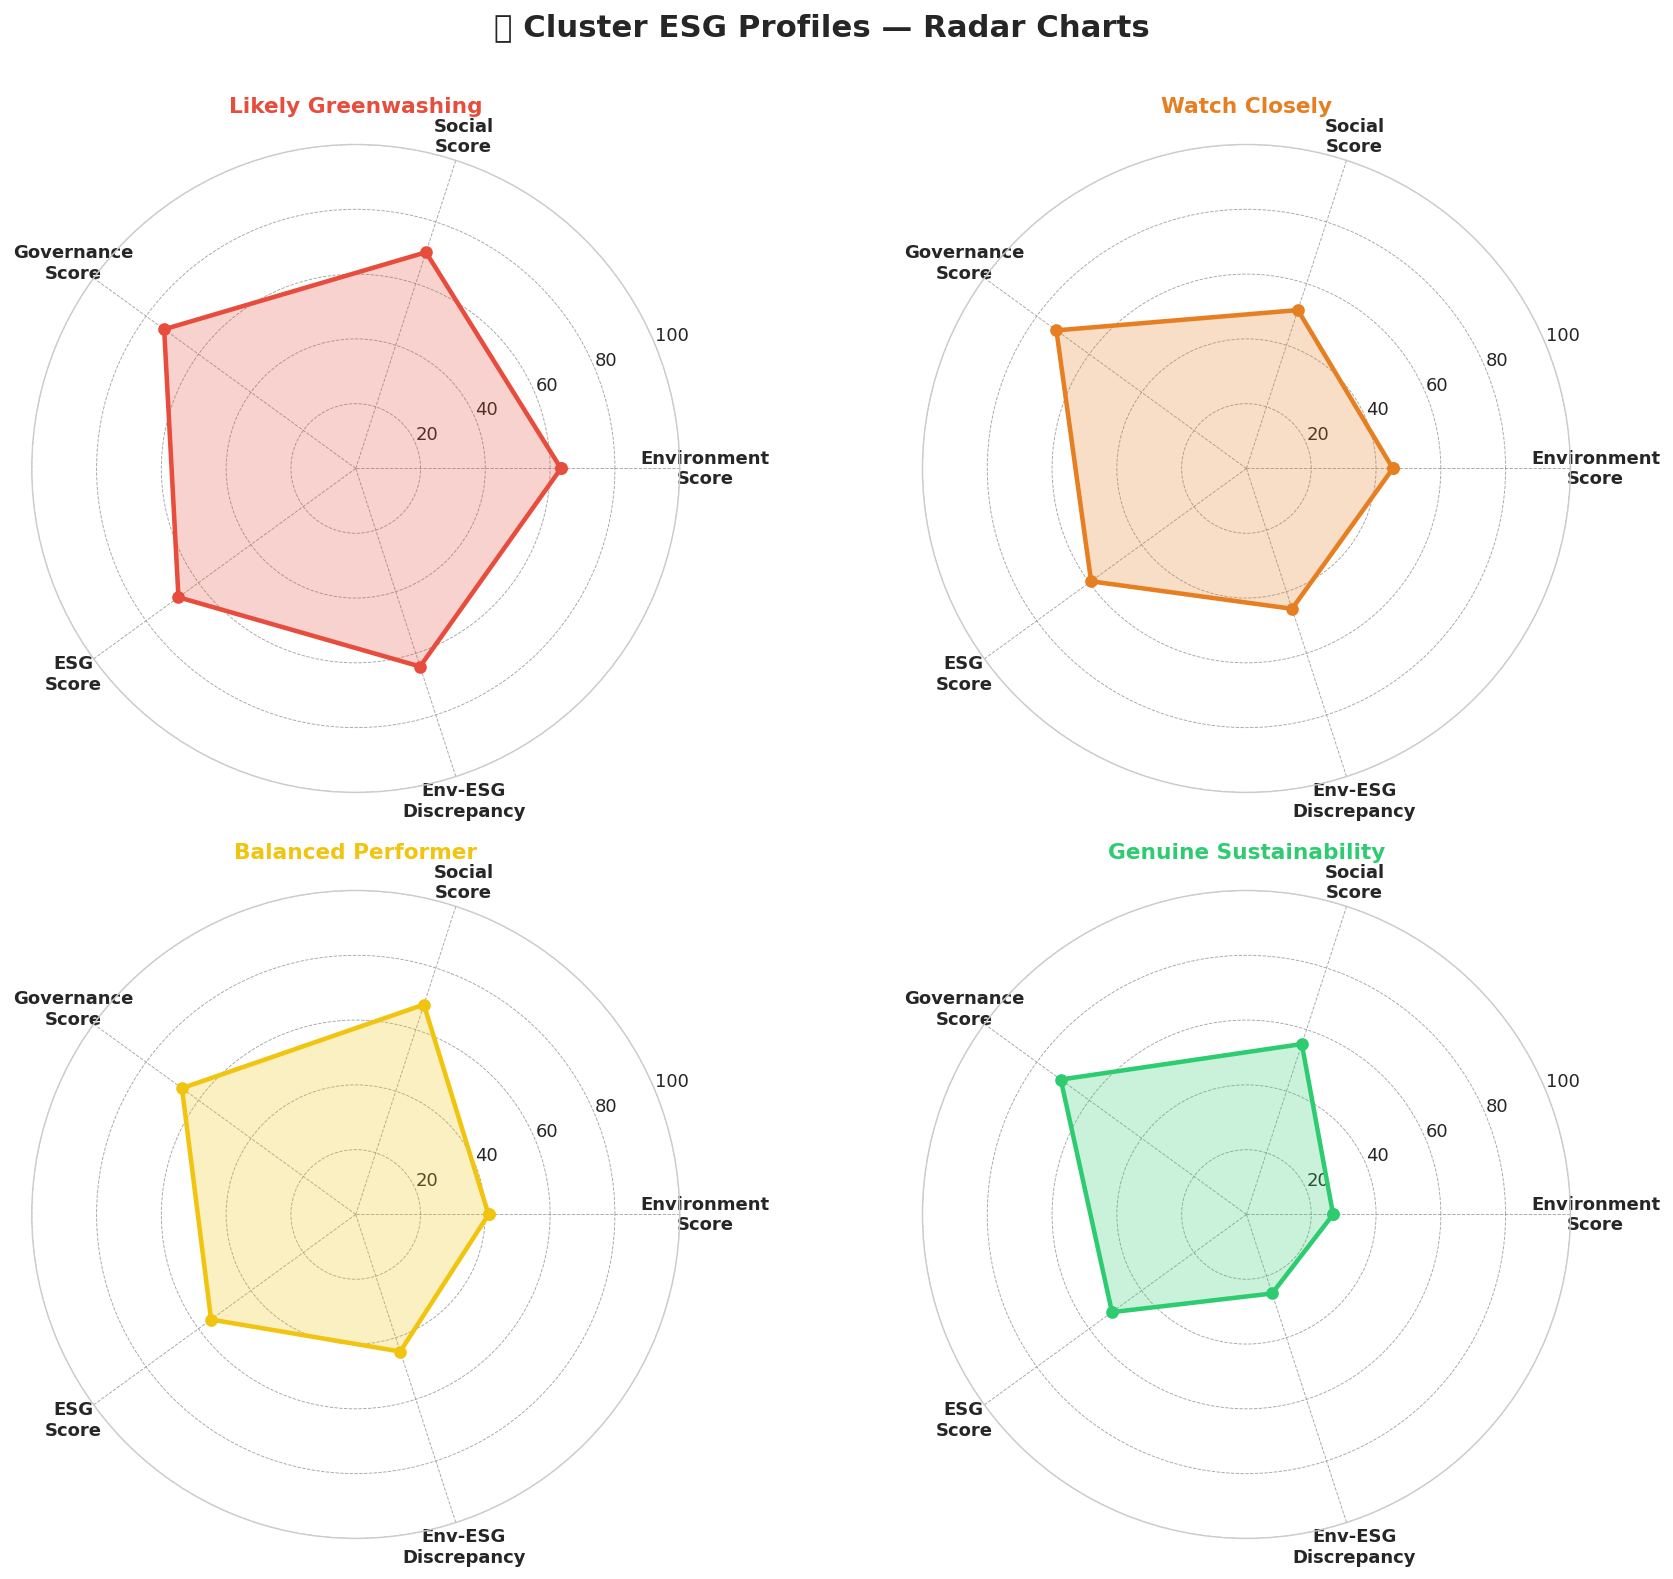

In [19]:
# ════════════════════════════════════════════════════════════════════════
# CHART 7: Cluster Radar Chart — Average ESG Pillar Comparison
# ════════════════════════════════════════════════════════════════════════
categories_radar = ['Environment\nScore', 'Social\nScore', 'Governance\nScore',
                    'ESG\nScore', 'Env-ESG\nDiscrepancy']
radar_features = ['Env_Score_Noisy', 'Soc_Score_Noisy', 'Gov_Score_Noisy',
                  'ESG_Noisy', 'Env_ESG_Discrepancy']

N = len(categories_radar)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close the loop

fig, axes = plt.subplots(2, 2, figsize=(14, 12), subplot_kw=dict(polar=True))
fig.suptitle('🕸️ Cluster ESG Profiles — Radar Charts', fontsize=17, fontweight='bold', y=1.01)

cluster_colors_list = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']

for idx, (ax, (cluster_id, cluster_label)) in enumerate(zip(axes.flatten(), cluster_name_map.items())):
    cluster_data = df[df['Cluster'] == cluster_id][radar_features].mean()
    values = cluster_data.values.tolist()
    # Normalize to 0-100 range for radar
    values_norm = [(v - df[f].min()) / (df[f].max() - df[f].min()) * 100
                   for v, f in zip(values, radar_features)]
    values_norm += values_norm[:1]

    color = cluster_colors_list[idx]
    ax.plot(angles, values_norm, 'o-', linewidth=2.5, color=color)
    ax.fill(angles, values_norm, alpha=0.25, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories_radar, size=10, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.set_title(cluster_label.split('—')[1].strip(), size=12, fontweight='bold',
                 color=color, pad=18)
    ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.7)

    count = (df['Cluster'] == cluster_id).sum()
    ax.text(0, -28, f"n = {count} companies", ha='center', size=10, color='gray',
            transform=ax.transData)

plt.tight_layout()
plt.savefig('chart7_radar.png', bbox_inches='tight', dpi=150)
plt.show()

## 🌳 Step 7: Decision Tree Classifier (Supervised ML)

**What this does:** We use the cluster labels (from K-Means) as training labels to build a Decision Tree that **learns the rules for predicting greenwashing risk**.

The tree will output: **which features matter most** and **clear if-then rules** investors can understand.

In [20]:
# ─── Define simplified greenwashing label ────────────────────────────────────
# Binary: 1 = Greenwashing Risk (High or Moderate), 0 = Clean (Low Risk or Safe)
high_risk_clusters = [k for k, v in cluster_name_map.items() if 'HIGH' in v or 'MODERATE' in v]
df['Greenwashing_Risk'] = df['Cluster'].apply(lambda x: 1 if x in high_risk_clusters else 0)

risk_count = df['Greenwashing_Risk'].value_counts()
print(f"🔴 Companies flagged as Greenwashing Risk: {risk_count.get(1, 0)} ({risk_count.get(1,0)/len(df)*100:.1f}%)")
print(f"🟢 Companies flagged as Clean/Safe:         {risk_count.get(0, 0)} ({risk_count.get(0,0)/len(df)*100:.1f}%)")

# ─── Features for the Decision Tree ──────────────────────────────────────────
tree_features = [
    'Env_Score_Noisy',
    'Soc_Score_Noisy',
    'Gov_Score_Noisy',
    'ESG_Noisy',
    'Env_ESG_Discrepancy',
    'Env_to_Social_Gap',
    'Composite_ESG',
    'Rating_vs_Composite_Gap',
    'Env_Weight_Ratio'
]
feature_labels = [
    'Env Score', 'Social Score', 'Gov Score', 'ESG Score',
    'Env-ESG Discrepancy', 'Env-Social Gap', 'Composite ESG',
    'Rating vs Composite Gap', 'Env Weight Ratio'
]

X = df[tree_features]
y = df['Greenwashing_Risk']

# ─── Train/Test Split ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(f"\n📊 Training set: {len(X_train)} companies")
print(f"📊 Test set:     {len(X_test)} companies")

🔴 Companies flagged as Greenwashing Risk: 515 (49.4%)
🟢 Companies flagged as Clean/Safe:         528 (50.6%)

📊 Training set: 782 companies
📊 Test set:     261 companies


In [21]:
# ─── Train Decision Tree ──────────────────────────────────────────────────────
dt = DecisionTreeClassifier(
    max_depth=5,          # Limit depth to avoid over-fitting
    min_samples_split=15, # Need at least 15 companies to split
    min_samples_leaf=8,   # Leaves must have at least 8 companies
    random_state=42,
    class_weight='balanced'
)
dt.fit(X_train, y_train)

# ─── Evaluate ─────────────────────────────────────────────────────────────────
y_pred = dt.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"✅ Decision Tree trained!")
print(f"🎯 Test Accuracy: {accuracy*100:.1f}%")
print("\n📋 Full Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Clean (0)', 'Greenwashing Risk (1)']))

✅ Decision Tree trained!
🎯 Test Accuracy: 93.9%

📋 Full Classification Report:
                       precision    recall  f1-score   support

            Clean (0)       0.95      0.92      0.94       132
Greenwashing Risk (1)       0.92      0.95      0.94       129

             accuracy                           0.94       261
            macro avg       0.94      0.94      0.94       261
         weighted avg       0.94      0.94      0.94       261



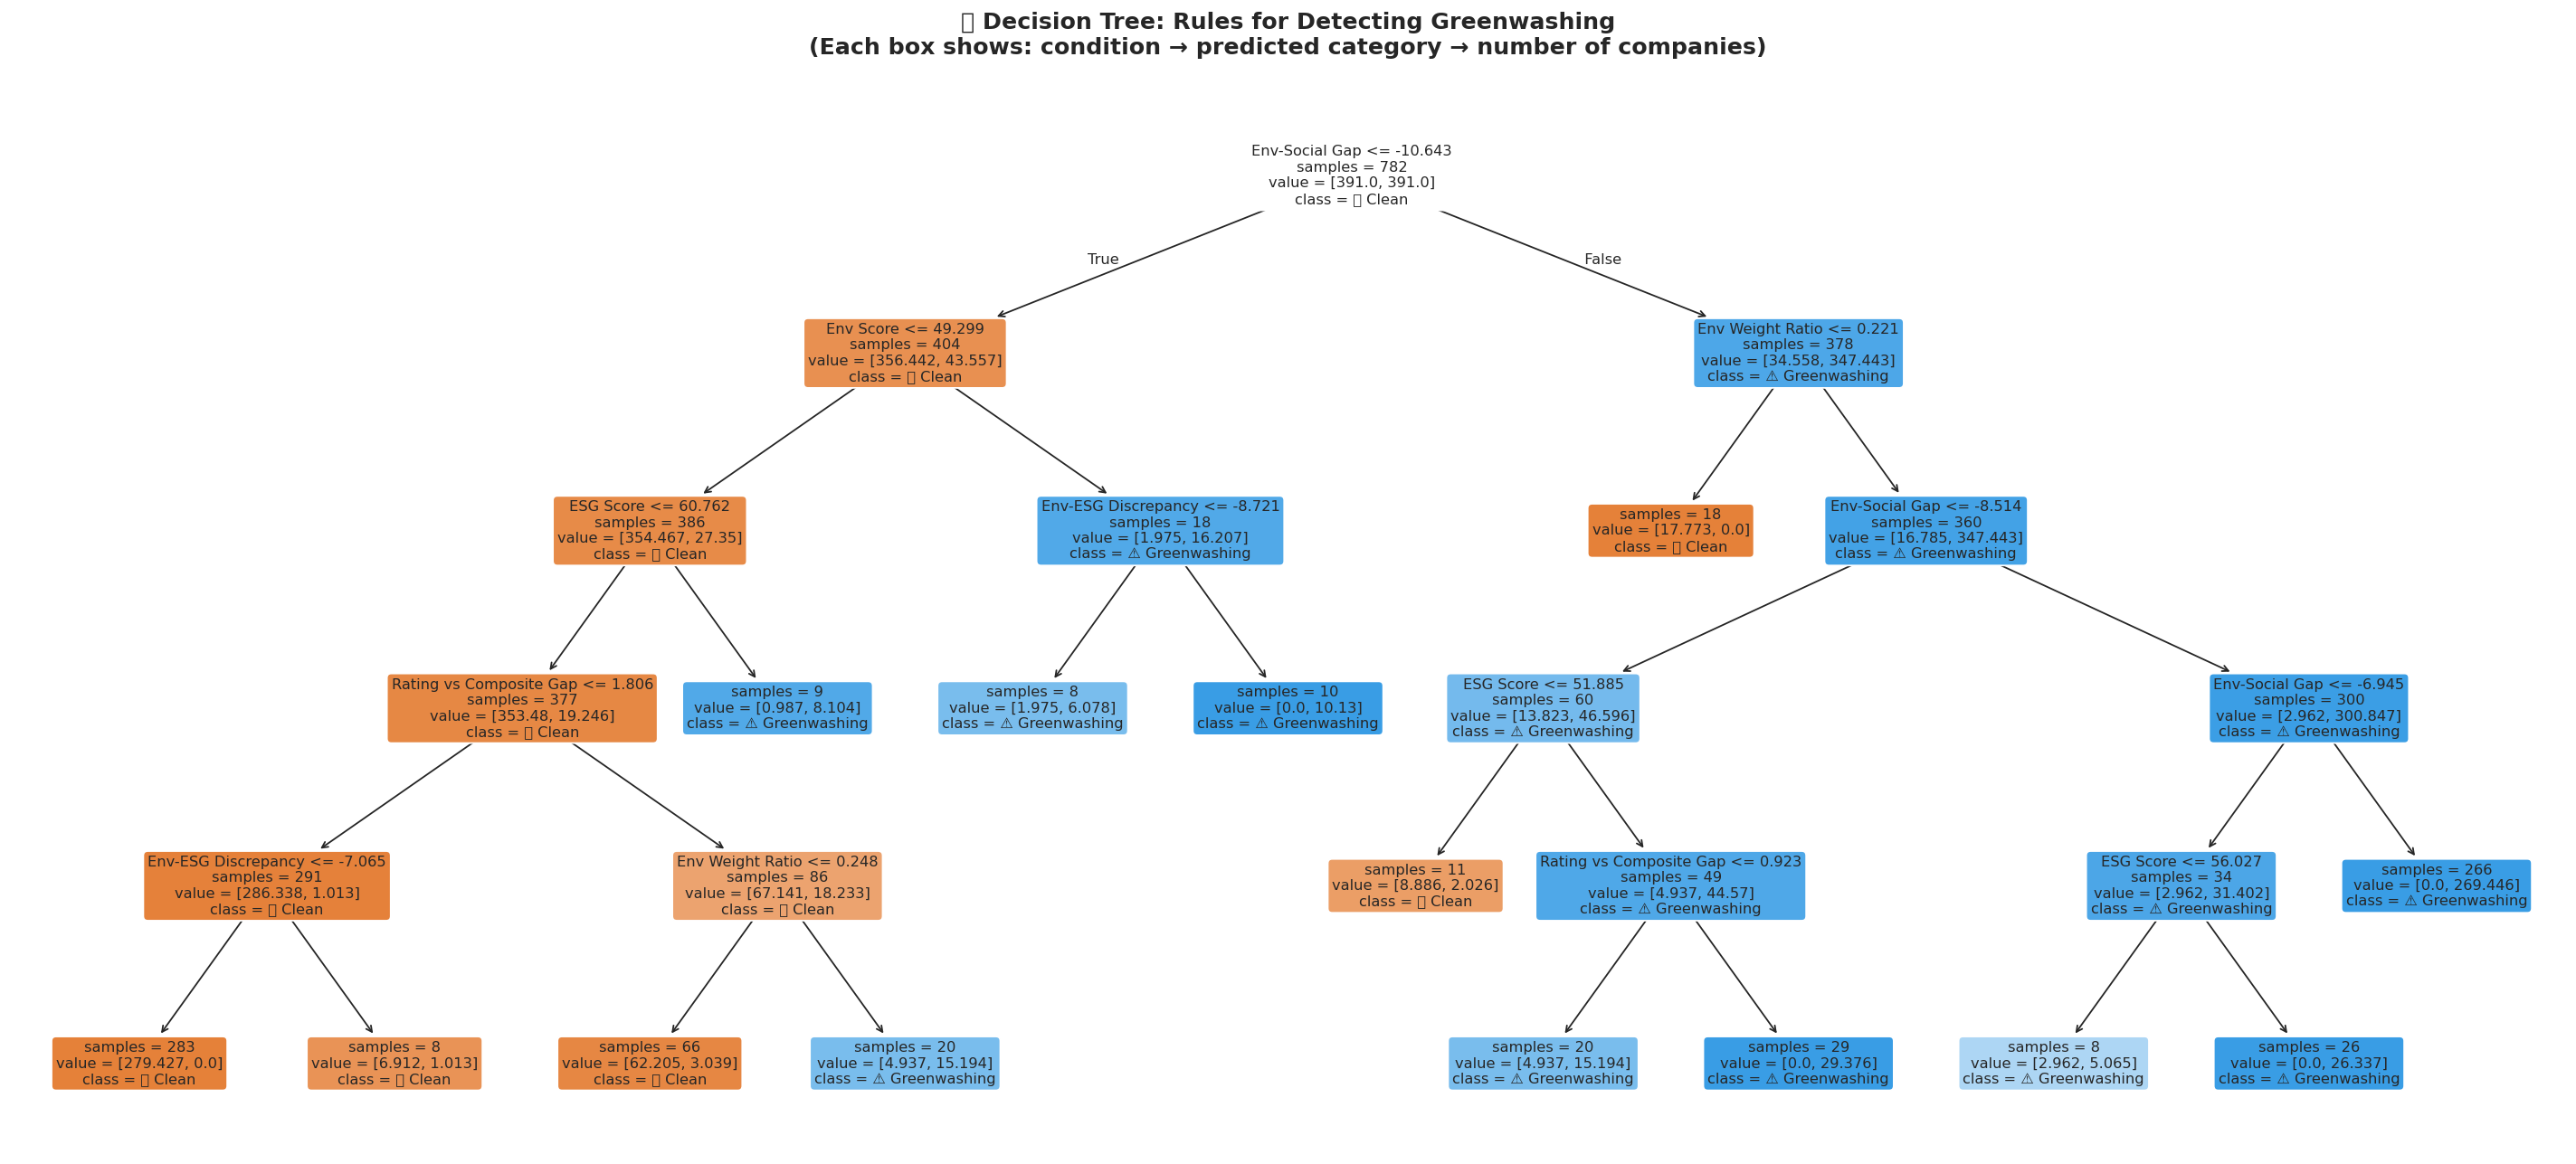

💡 Green boxes = Clean companies  |  Orange boxes = Greenwashing risk


In [22]:
# ════════════════════════════════════════════════════════════════════════
# CHART 8: Decision Tree Visualization
# ════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt,
    feature_names=feature_labels,
    class_names=['✅ Clean', '⚠️ Greenwashing'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=False,
    proportion=False
)
ax.set_title('🌳 Decision Tree: Rules for Detecting Greenwashing\n'
             '(Each box shows: condition → predicted category → number of companies)',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('chart8_decision_tree.png', bbox_inches='tight', dpi=130)
plt.show()
print("💡 Green boxes = Clean companies  |  Orange boxes = Greenwashing risk")

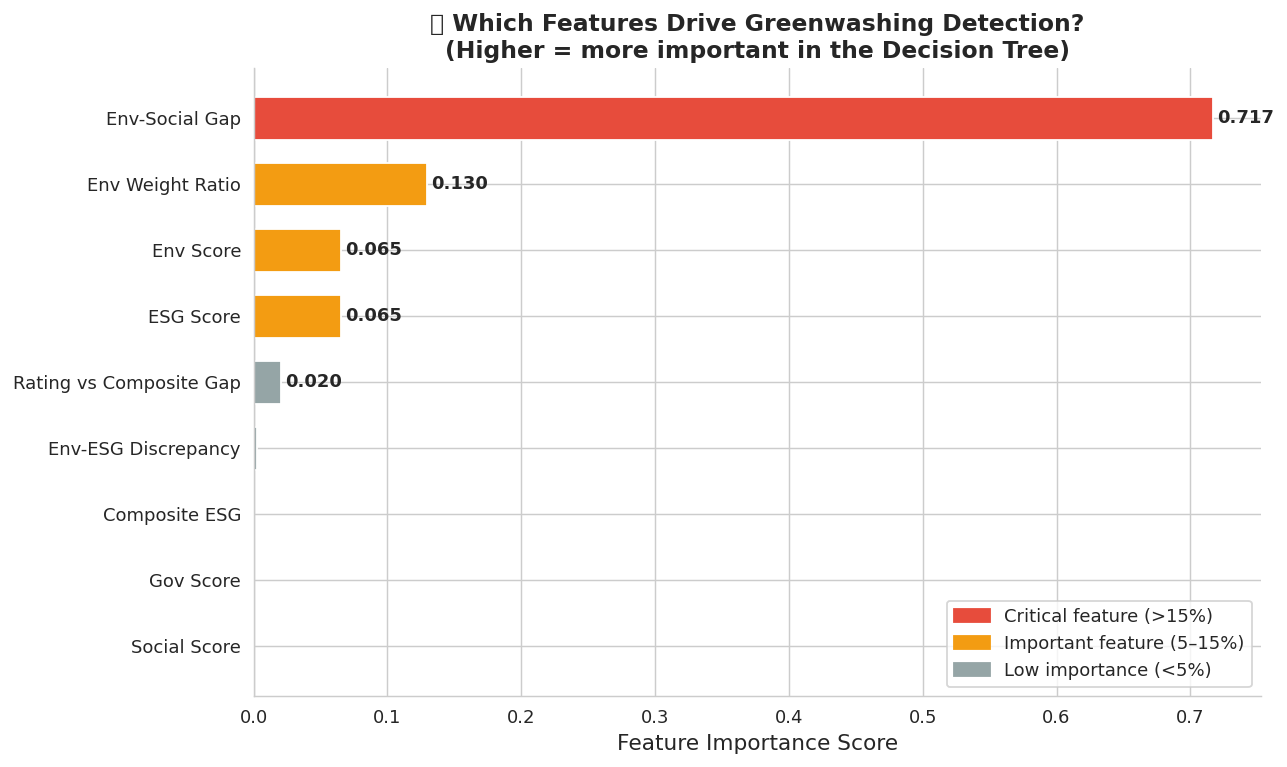

In [23]:
# ════════════════════════════════════════════════════════════════════════
# CHART 9: Feature Importance — What Drives Greenwashing Detection?
# ════════════════════════════════════════════════════════════════════════
importance_df = pd.DataFrame({
    'Feature': feature_labels,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = ['#e74c3c' if imp > 0.15 else '#f39c12' if imp > 0.05 else '#95a5a6'
              for imp in importance_df['Importance']]
bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color=colors_imp, edgecolor='white', height=0.65)

# Add value labels
for bar, val in zip(bars, importance_df['Importance']):
    if val > 0.01:
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('🏆 Which Features Drive Greenwashing Detection?\n'
             '(Higher = more important in the Decision Tree)', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
legend_patches = [
    mpatches.Patch(color='#e74c3c', label='Critical feature (>15%)'),
    mpatches.Patch(color='#f39c12', label='Important feature (5–15%)'),
    mpatches.Patch(color='#95a5a6', label='Low importance (<5%)')
]
ax.legend(handles=legend_patches, loc='lower right')
plt.tight_layout()
plt.savefig('chart9_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

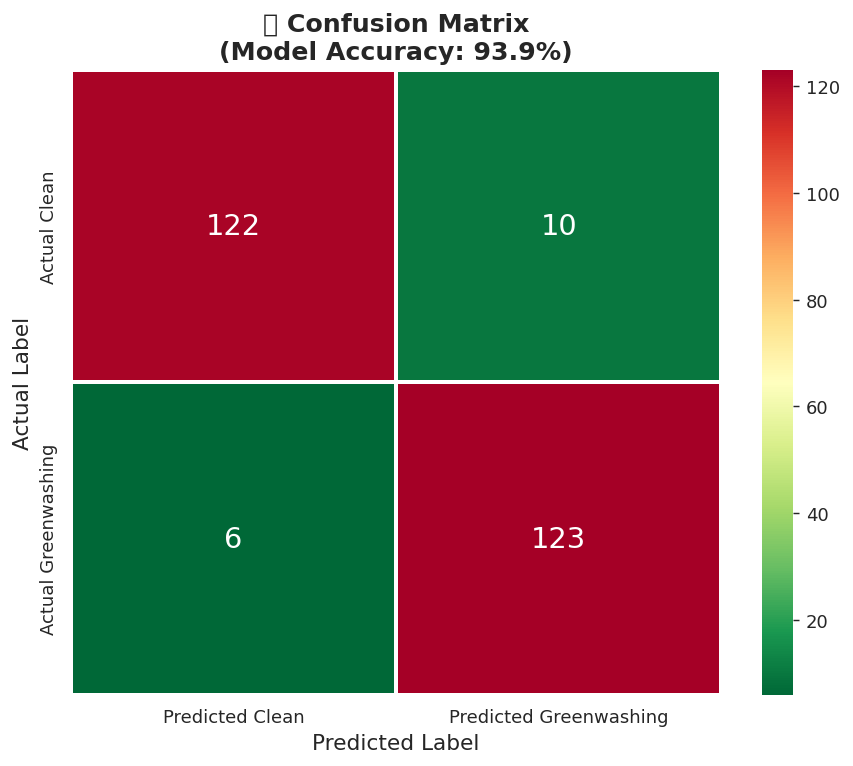

💡 Diagonal = correct predictions | Off-diagonal = errors


In [24]:
# ════════════════════════════════════════════════════════════════════════
# CHART 10: Confusion Matrix
# ════════════════════════════════════════════════════════════════════════
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r',
            xticklabels=['Predicted Clean', 'Predicted Greenwashing'],
            yticklabels=['Actual Clean', 'Actual Greenwashing'],
            linewidths=2, linecolor='white', ax=ax, annot_kws={'size': 16})
ax.set_title(f'🎯 Confusion Matrix\n(Model Accuracy: {accuracy*100:.1f}%)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Actual Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('chart10_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print("💡 Diagonal = correct predictions | Off-diagonal = errors")

## 📈 Step 8: Sector-Level Greenwashing Analysis

In [25]:
# ════════════════════════════════════════════════════════════════════════
# CHART 11: Sector Risk Dashboard
# ════════════════════════════════════════════════════════════════════════
sector_risk = df.groupby('Sector classification').agg(
    Greenwashing_Rate=('Greenwashing_Risk', 'mean'),
    Company_Count=('Greenwashing_Risk', 'count'),
    Avg_Discrepancy=('Env_ESG_Discrepancy', 'mean'),
    Avg_ESG=('ESG_Noisy', 'mean')
).reset_index()

# Keep only sectors with at least 5 companies for reliability
sector_risk = sector_risk[sector_risk['Company_Count'] >= 5].sort_values('Greenwashing_Rate', ascending=False)
sector_risk['Greenwashing_Rate_Pct'] = (sector_risk['Greenwashing_Rate'] * 100).round(1)

fig = px.bar(
    sector_risk.head(20),
    x='Greenwashing_Rate_Pct',
    y='Sector classification',
    color='Greenwashing_Rate_Pct',
    color_continuous_scale='RdYlGn_r',
    orientation='h',
    text='Greenwashing_Rate_Pct',
    hover_data=['Company_Count', 'Avg_Discrepancy', 'Avg_ESG'],
    title='🏭 Greenwashing Risk Rate by Sector<br><sup>% of companies in each sector flagged as greenwashing risk</sup>',
    labels={'Greenwashing_Rate_Pct': 'Greenwashing Risk Rate (%)', 'Sector classification': 'Sector'},
    width=950, height=600
)
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, showlegend=False)
fig.show()

## 🔮 Step 9: Future Prediction Tool

This section lets you **input any company's ESG scores and instantly get a greenwashing risk prediction!**

In [26]:
# ════════════════════════════════════════════════════════════════════════
# 🔮 PREDICTION FUNCTION — Predict greenwashing risk for ANY company
# ════════════════════════════════════════════════════════════════════════

def predict_greenwashing_risk(company_name, env_score, social_score, gov_score, esg_numeric_score):
    """
    Predicts greenwashing risk for a company.

    Parameters:
    -----------
    company_name     : str   — Name of the company
    env_score        : float — Environment score (0–100)
    social_score     : float — Social score (0–100)
    gov_score        : float — Governance score (0–100)
    esg_numeric_score: float — Overall ESG rating score (0–100)
    """
    # Add small noise (simulating real-world data uncertainty)
    env   = env_score   + np.random.normal(0, 1.5)
    soc   = social_score + np.random.normal(0, 1.2)
    gov   = gov_score   + np.random.normal(0, 1.0)
    esg   = esg_numeric_score + np.random.normal(0, 1.0)

    # Derived features
    discrepancy  = env - esg
    env_soc_gap  = env - soc
    composite    = (env + soc + gov) / 3
    rating_gap   = esg - composite
    env_weight   = env / (env + soc + gov)

    features = pd.DataFrame([{
        'Env_Score_Noisy': env,
        'Soc_Score_Noisy': soc,
        'Gov_Score_Noisy': gov,
        'ESG_Noisy': esg,
        'Env_ESG_Discrepancy': discrepancy,
        'Env_to_Social_Gap': env_soc_gap,
        'Composite_ESG': composite,
        'Rating_vs_Composite_Gap': rating_gap,
        'Env_Weight_Ratio': env_weight
    }])

    prediction = dt.predict(features)[0]
    proba = dt.predict_proba(features)[0]

    print("=" * 60)
    print(f"  🏢 Company: {company_name}")
    print("=" * 60)
    print(f"  🌱 Environment Score  : {env_score}")
    print(f"  🤝 Social Score       : {social_score}")
    print(f"  🏛️  Governance Score  : {gov_score}")
    print(f"  ⭐ ESG Rating Score   : {esg_numeric_score}")
    print("─" * 60)
    print(f"  ⚡ Env–ESG Discrepancy: {discrepancy:.2f} pts  ", end="")
    print("⚠️ HIGH" if discrepancy > 10 else "✅ NORMAL")
    print(f"  📊 Composite Fair Score: {composite:.2f}")
    print("─" * 60)

    if prediction == 1:
        print(f"  🔴 VERDICT: GREENWASHING RISK DETECTED")
        print(f"  📉 Risk Probability  : {proba[1]*100:.1f}%")
        print("  ⚠️  Investor Warning : ESG performance may be overstated")
    else:
        print(f"  🟢 VERDICT: LOW GREENWASHING RISK")
        print(f"  ✅ Clean Probability : {proba[0]*100:.1f}%")
        print("  👍 Investor Signal   : ESG claims appear consistent")

    print("=" * 60)


# ─── Example predictions ──────────────────────────────────────────────────────
print("🧪 Running example predictions...\n")

# Company 1: Classic greenwasher (high env, low ESG)
predict_greenwashing_risk(
    company_name="SolarFront Industries (Example)",
    env_score=78,
    social_score=41,
    gov_score=39,
    esg_numeric_score=44
)

print()

# Company 2: Genuinely sustainable
predict_greenwashing_risk(
    company_name="GreenBalance Corp (Example)",
    env_score=72,
    social_score=70,
    gov_score=74,
    esg_numeric_score=71
)

🧪 Running example predictions...

  🏢 Company: SolarFront Industries (Example)
  🌱 Environment Score  : 78
  🤝 Social Score       : 41
  🏛️  Governance Score  : 39
  ⭐ ESG Rating Score   : 44
────────────────────────────────────────────────────────────
  ⚡ Env–ESG Discrepancy: 32.78 pts  ⚠️ HIGH
  📊 Composite Fair Score: 51.98
────────────────────────────────────────────────────────────
  🔴 VERDICT: GREENWASHING RISK DETECTED
  📉 Risk Probability  : 100.0%
  ⚠️  Investor Warning : ESG performance may be overstated

  🏢 Company: GreenBalance Corp (Example)
  🌱 Environment Score  : 72
  🤝 Social Score       : 70
  🏛️  Governance Score  : 74
  ⭐ ESG Rating Score   : 71
────────────────────────────────────────────────────────────
  ⚡ Env–ESG Discrepancy: 1.33 pts  ✅ NORMAL
  📊 Composite Fair Score: 72.72
────────────────────────────────────────────────────────────
  🔴 VERDICT: GREENWASHING RISK DETECTED
  📉 Risk Probability  : 100.0%
  ⚠️  Investor Warning : ESG performance may be overstat

In [27]:
# ─── 🚀 TEST YOUR OWN COMPANY — Just change the values below! ────────────────
# Replace the values inside the function with your company's scores

predict_greenwashing_risk(
    company_name="Your Company Name Here",   # ← Change this
    env_score=60,                             # ← Environment score (0–100)
    social_score=55,                          # ← Social score (0–100)
    gov_score=65,                             # ← Governance score (0–100)
    esg_numeric_score=58                      # ← Overall ESG rating score
)

  🏢 Company: Your Company Name Here
  🌱 Environment Score  : 60
  🤝 Social Score       : 55
  🏛️  Governance Score  : 65
  ⭐ ESG Rating Score   : 58
────────────────────────────────────────────────────────────
  ⚡ Env–ESG Discrepancy: 3.00 pts  ✅ NORMAL
  📊 Composite Fair Score: 59.65
────────────────────────────────────────────────────────────
  🔴 VERDICT: GREENWASHING RISK DETECTED
  📉 Risk Probability  : 100.0%
  ⚠️  Investor Warning : ESG performance may be overstated


## 📊 Step 10: Final Summary Dashboard

In [28]:
# ════════════════════════════════════════════════════════════════════════
# CHART 12: Combined Summary — Top Greenwashing Risk Companies
# ════════════════════════════════════════════════════════════════════════

# Get top 20 greenwashing suspects (highest discrepancy)
suspects = df[df['Greenwashing_Risk'] == 1].nlargest(20, 'Env_ESG_Discrepancy')[
    ['Company Name', 'Sector classification', 'Env_Score_Noisy',
     'ESG_Noisy', 'Env_ESG_Discrepancy', 'Cluster_Label']
].copy()
suspects.columns = ['Company', 'Sector', 'Env Score', 'ESG Score', 'Discrepancy', 'Risk Level']
suspects = suspects.round(1)

fig = go.Figure(data=[
    go.Table(
        header=dict(
            values=['<b>Company</b>', '<b>Sector</b>', '<b>Env Score</b>',
                    '<b>ESG Score</b>', '<b>Discrepancy ⚠️</b>', '<b>Risk Level</b>'],
            fill_color='#2c3e50',
            align='left',
            font=dict(color='white', size=12)
        ),
        cells=dict(
            values=[suspects[c].tolist() for c in suspects.columns],
            fill_color=[
                ['#fdfefe'] * len(suspects),
                ['#fdfefe'] * len(suspects),
                [f'rgba(231,76,60,{min(0.1 + v/200, 0.5)})' for v in suspects['Env Score']],
                [f'rgba(52,152,219,{min(0.1 + v/200, 0.5)})' for v in suspects['ESG Score']],
                [f'rgba(231,76,60,{min(0.2 + v/80, 0.8)})' for v in suspects['Discrepancy']],
                ['#fff3cd'] * len(suspects),
            ],
            align='left',
            font=dict(size=11)
        )
    )
])

fig.update_layout(
    title='🔴 Top 20 Companies Flagged for Greenwashing Risk<br><sup>Sorted by Environment–ESG Discrepancy (higher = more suspicious)</sup>',
    width=1000, height=680
)
fig.show()

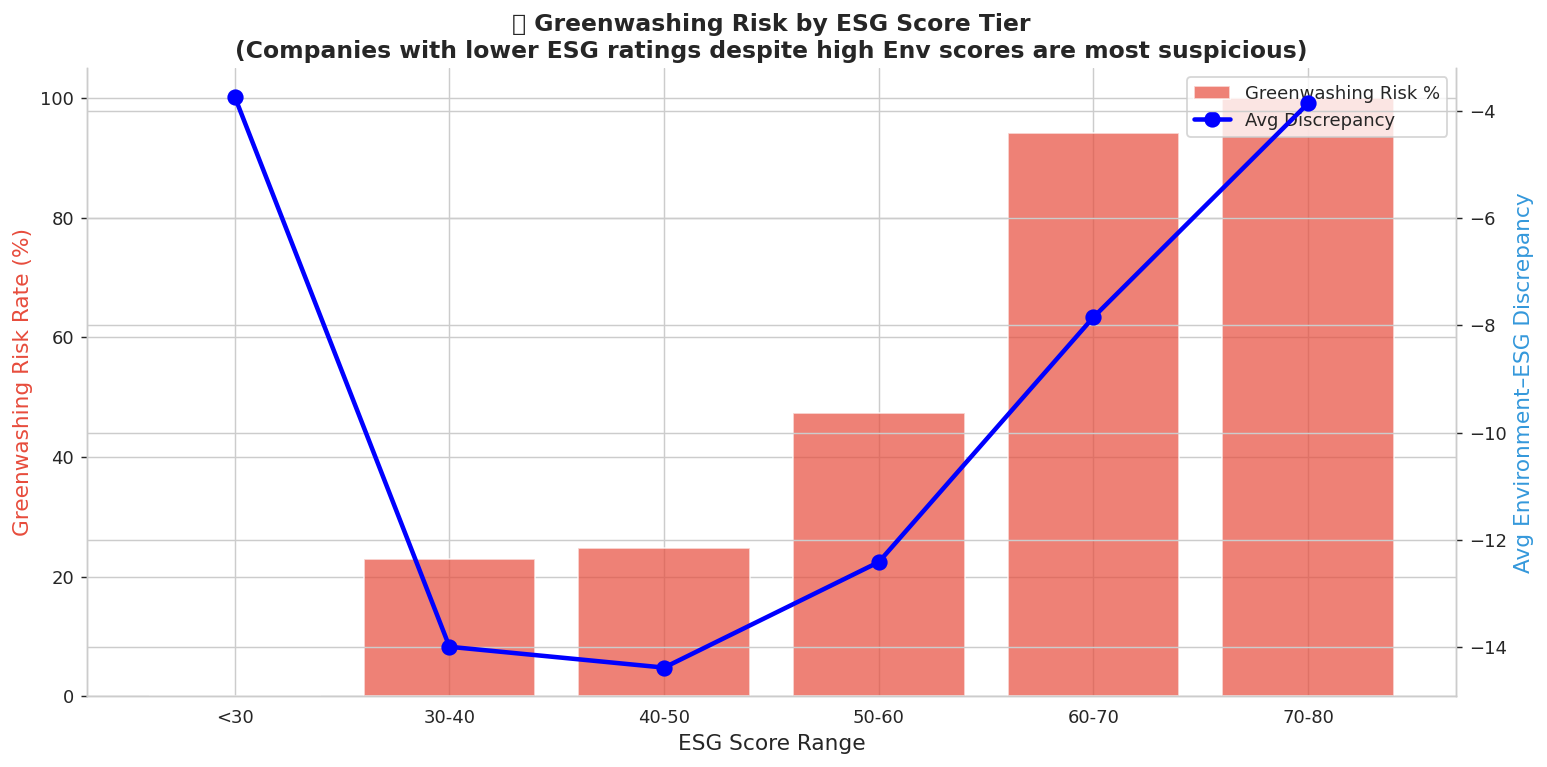

In [29]:
# ════════════════════════════════════════════════════════════════════════
# CHART 13: Greenwashing Risk Over ESG Score Range (Future Trend)
# ════════════════════════════════════════════════════════════════════════
df['ESG_Bin'] = pd.cut(df['ESG_Noisy'], bins=[0,30,40,50,60,70,80,100],
                        labels=['<30','30-40','40-50','50-60','60-70','70-80','80+'])

risk_by_esg = df.groupby('ESG_Bin', observed=True).agg(
    Risk_Rate=('Greenwashing_Risk','mean'),
    Count=('Greenwashing_Risk','count'),
    Avg_Discrepancy=('Env_ESG_Discrepancy','mean')
).reset_index()
risk_by_esg['Risk_Pct'] = risk_by_esg['Risk_Rate'] * 100

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

bars = ax1.bar(risk_by_esg['ESG_Bin'].astype(str), risk_by_esg['Risk_Pct'],
               color='#e74c3c', alpha=0.7, edgecolor='white', label='Greenwashing Risk %')
line = ax2.plot(risk_by_esg['ESG_Bin'].astype(str), risk_by_esg['Avg_Discrepancy'],
                'bo-', linewidth=2.5, markersize=8, label='Avg Discrepancy')

ax1.set_xlabel('ESG Score Range', fontsize=12)
ax1.set_ylabel('Greenwashing Risk Rate (%)', color='#e74c3c', fontsize=12)
ax2.set_ylabel('Avg Environment–ESG Discrepancy', color='#3498db', fontsize=12)
ax1.set_title('📈 Greenwashing Risk by ESG Score Tier\n'
              '(Companies with lower ESG ratings despite high Env scores are most suspicious)',
              fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig('chart13_trend.png', bbox_inches='tight', dpi=150)
plt.show()

In [31]:
# ════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY PRINTOUT
# ════════════════════════════════════════════════════════════════════════
print("\n" + "═"*65)
print("  🌿 GREENWASHING DETECTION MODEL — FINAL SUMMARY")
print("═"*65)
print(f"  📊 Dataset        : {len(df)} Indian companies (CRISIL ESG)")
print(f"  🤖 Methods        : K-Means Clustering (k=4) + Decision Tree")
print(f"  🎯 Model Accuracy : {accuracy*100:.1f}%")
print("─"*65)

for cid, name in cluster_name_map.items():
    count = (df['Cluster'] == cid).sum()
    avg_disc = df[df['Cluster'] == cid]['Env_ESG_Discrepancy'].mean()
    print(f"  {name} — {count} companies (avg discrepancy: {avg_disc:.1f} pts)")

print("─"*65)
total_risk = df['Greenwashing_Risk'].sum()
print(f"  🔴 Total companies flagged : {total_risk} ({total_risk/len(df)*100:.1f}%)")
print(f"  🟢 Total companies clean   : {len(df)-total_risk} ({(len(df)-total_risk)/len(df)*100:.1f}%)")
print("─"*65)
top_feat = importance_df.tail(1)['Feature'].values[0]
print(f"  🏆 Most predictive feature : {top_feat}")
print("─"*65)
top_sector = sector_risk.iloc[0]
print(f"  ⚠️  Highest risk sector    : {top_sector['Sector classification']} ({top_sector['Greenwashing_Rate_Pct']}%)")
print("═"*65)
print("  ✅ Analysis complete! Use the prediction cell above to")
print("     test any company's greenwashing risk.")
print("═"*65)


═════════════════════════════════════════════════════════════════
  🌿 GREENWASHING DETECTION MODEL — FINAL SUMMARY
═════════════════════════════════════════════════════════════════
  📊 Dataset        : 1043 Indian companies (CRISIL ESG)
  🤖 Methods        : K-Means Clustering (k=4) + Decision Tree
  🎯 Model Accuracy : 93.9%
─────────────────────────────────────────────────────────────────
  🔴 HIGH RISK — Likely Greenwashing — 251 companies (avg discrepancy: -4.5 pts)
  🟠 MODERATE RISK — Watch Closely — 264 companies (avg discrepancy: -12.0 pts)
  🟡 LOW RISK — Balanced Performer — 296 companies (avg discrepancy: -12.4 pts)
  🟢 SAFE — Genuine Sustainability — 232 companies (avg discrepancy: -20.0 pts)
─────────────────────────────────────────────────────────────────
  🔴 Total companies flagged : 515 (49.4%)
  🟢 Total companies clean   : 528 (50.6%)
─────────────────────────────────────────────────────────────────
  🏆 Most predictive feature : Env-Social Gap
─────────────────────────────

---
## 📖 How to Interpret the Results — Investor Guide

| Signal | What it Means | Investor Action |
|--------|--------------|----------------|
| **High Env–ESG Discrepancy (>10 pts)** | Company scores high on environment but overall ESG is low — mismatch suggests misleading claims | 🔴 Investigate further before investing |
| **Cluster: HIGH RISK** | Grouped with known greenwashing patterns by K-Means | 🔴 Avoid or demand transparency |
| **Cluster: SAFE** | Consistent across all three pillars, no discrepancy | 🟢 Strong sustainability signal |
| **High Env Weight Ratio** | Company's score is dominated by environment, neglecting social/governance | 🟡 Dig into social and governance practices |
| **Decision Tree: Risk=1** | Model predicts greenwashing based on learned patterns | 🔴 Flag for deeper due diligence |
